# Import libraries and data

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [2]:

pd.DataFrame(load_breast_cancer(as_frame=True)['data'])

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [3]:
pd.DataFrame(load_breast_cancer(as_frame=True)['target'])

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [4]:
X,y = load_breast_cancer(return_X_y=True)

In [5]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


# Train test split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=2
                                                    )

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
X_train

array([[-0.01330339,  1.7757658 , -0.01491962, ..., -0.13236958,
        -1.08014517, -0.03527943],
       [-0.8448276 , -0.6284278 , -0.87702746, ..., -1.11552632,
        -0.85773964, -0.72098905],
       [ 1.44755936,  0.71180168,  1.47428816, ...,  0.87583964,
         0.4967602 ,  0.46321706],
       ...,
       [-0.46608541, -1.49375484, -0.53234924, ..., -1.32388956,
        -1.02997851, -0.75145272],
       [-0.50025764, -1.62161319, -0.527814  , ..., -0.0987626 ,
         0.35796577, -0.43906159],
       [ 0.96060511,  1.21181916,  1.00427242, ...,  0.8956983 ,
        -1.23064515,  0.50697397]])

# fit model

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [10]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [11]:
# calcuate predication value
y_predict = knn.predict(X_test)
y_predict

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0])

# Accuracy score

In [12]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.9736842105263158

# How to Select k

## Heuotic 

## Cross Validation

In [13]:
scores = []

for i in range(1,16):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    
    knn.fit(X_train,y_train)
    
    y_pred = knn.predict(X_test)
    
    scores.append(accuracy_score(y_test,y_pred))
    
scores

[0.956140350877193,
 0.9473684210526315,
 0.9912280701754386,
 0.9824561403508771,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9824561403508771,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9736842105263158,
 0.9649122807017544]

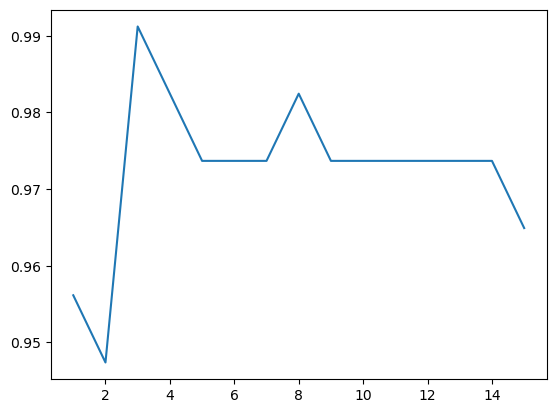

In [14]:
import matplotlib.pyplot as plt 

plt.plot(range(1,16),scores)

Tho k = 3 par maximum accuracy score aa raha ha use it

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()
    
cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y))

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

<function __main__.plot_decision_boundaries(n_neighbors, data, labels)>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn import neighbors, datasets
from sklearn.preprocessing import StandardScaler
from ipywidgets import interact, fixed

def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.show()
    
cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y))

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

<function __main__.plot_decision_boundaries(n_neighbors, data, labels)>

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import fixed, interact
from mlxtend.plotting import plot_decision_regions
from sklearn import datasets, neighbors
from sklearn.preprocessing import StandardScaler


def load_data():
    cancer = datasets.load_breast_cancer()
    return cancer


def plot_decision_boundaries(n_neighbors, data, labels):
    # Initialize and train the KNN Classifier
    clf = neighbors.KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    # Plot the decision surface using mlxtend
    plt.figure(figsize=(8, 6))
    plot_decision_regions(X=data, y=labels, clf=clf, legend=2)

    # Set metadata labels
    plt.title(f"2-Class classification (k = {n_neighbors})")
    plt.xlabel("Feature 1 (Standardized)")
    plt.ylabel("Feature 2 (Standardized)")
    plt.show()


cancer = load_data()

# Use only the first two features and standardize them.
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Interactive widget
interact(
    plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X), labels=fixed(y)
)


interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

<function __main__.plot_decision_boundaries(n_neighbors, data, labels)>

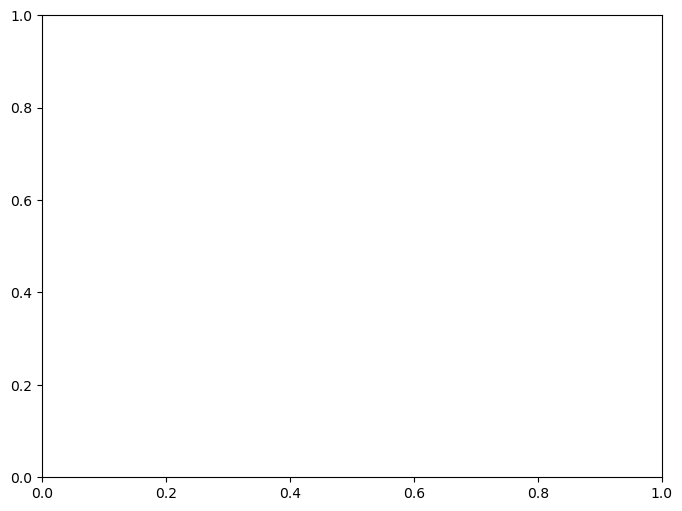

interactive(children=(IntSlider(value=5, continuous_update=False, description='k Value:', max=20, min=1), Outp…

<function __main__.plot_decision_boundaries(n_neighbors, data, labels)>

In [18]:
import matplotlib.pyplot as plt
from ipywidgets import fixed, interact, IntSlider
from mlxtend.plotting import plot_decision_regions
from sklearn import datasets, neighbors
from sklearn.preprocessing import StandardScaler


def load_data():
    return datasets.load_breast_cancer()


def plot_decision_boundaries(n_neighbors, data, labels):
    # Initialize and quickly fit the KNN Classifier
    clf = neighbors.KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
    clf.fit(data, labels)

    plt.figure(figsize=(8, 6))

    # FIX: Removed the invalid 'res' parameter to eliminate the TypeError.
    # 'zoom_factor' handles background rendering scaling if needed, 
    # but continuous_update=False is already doing the heavy lifting for speed.
    plot_decision_regions(X=data, y=labels, clf=clf, legend=2)

    # Clean styling elements
    plt.title(f"Instant 2-Class KNN classification (k = {n_neighbors})")
    plt.xlabel("Feature 1 (Standardized)")
    plt.ylabel("Feature 2 (Standardized)")
    plt.show()


# Load and scale data once globally
cancer = load_data()
X = StandardScaler().fit_transform(cancer.data[:, :2])
y = cancer.target

# Optimization: Stop continuous tracking while dragging the mouse
k_slider = IntSlider(
    value=5, min=1, max=20, step=1, description="k Value:", continuous_update=False
)

# Run interactive widget smoothly without crashes
interact(plot_decision_boundaries, n_neighbors=k_slider, data=fixed(X), labels=fixed(y))


# Coding KNN from Scratch 
The algorithum

we have to make a class and then our class result and the knn algo result should be same 

In [ ]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [ ]:
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
        
    def predict(self,X_test):
        # caculate distance
        # sort the distance
        # majority count
        for i in X_test:
            print(i)
            
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train)
knn_object.predict(X_test)

[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]
[ 0.24583601 -0.06219797  0.21802678  0.10121824 -0.42922355 -0.10019232
 -0.35318763  0.00529171  0.26979766 -0.61677593 -0.3930604  -0.48952076
 -0.3153669  -0.312382   -0.54677409 -0.23233346 -0.5963459   0.04235418
 -0.65758939 -0.38635042  0.01399046  0.06446126  0.07400049 -0.10539076
 -0.02219052  0.31991294 -0.42866144  0.54129749  0.11047691  0.0483572 ]
[-1.26115925 -0.29051645 -1.26499659 -1.03398179 -0.90745995 -0.94328279
 -0.93032276 -1.09475492 -0.47607524  0.19789291 -0.20008179  0.18306164
 -0.26451098 -0.39586618  1.32378629 -0.72014764 -0.78958733 -1.31398919
  0.80361402 -0.31809916 -1.06178869 -0.18807741 

In [ ]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def caluate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.caluate_distance(i,j))
                
        return print(distances)
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

[6.715706304617479, 8.970896955841553, 4.896263045139602, 6.23700037235829, 5.486638895891515, 7.314472566336465, 8.945239715580996, 9.536128294160473, 4.776293778554568, 6.533462713198622, 6.450352052291501, 12.526126434842663, 11.599830045259246, 4.360964802078157, 5.749017266936892, 9.084468290473719, 5.948089021042134, 5.358032868010988, 6.371806619285273, 7.705313571438155, 5.665130583286102, 7.233673625630805, 8.333011855950211, 8.306977659674546, 7.3017059187558075, 6.02178885856282, 9.406157539549907, 7.727307331939359, 4.8967481181490555, 7.236293904166328, 4.674948507465405, 8.271971566061078, 9.026936143962278, 6.668815530760772, 3.375414891516928, 13.733273731327827, 7.5814148923747, 6.566160431485855, 9.255867809349683, 20.1527500453832, 6.9467282433768816, 8.73197662273164, 4.380822416211134, 9.624992161412449, 6.777986664461411, 8.830004454777749, 7.979137287283137, 5.1656720145220625, 3.6936521485310183, 7.732424915874049, 9.14572496050262, 6.659902395649314, 4.23483446

In [ ]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def caluate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.caluate_distance(i,j))
                
        # sort the distances
        return print(list(enumerate(distances)))
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

[(0, 6.715706304617479), (1, 8.970896955841553), (2, 4.896263045139602), (3, 6.23700037235829), (4, 5.486638895891515), (5, 7.314472566336465), (6, 8.945239715580996), (7, 9.536128294160473), (8, 4.776293778554568), (9, 6.533462713198622), (10, 6.450352052291501), (11, 12.526126434842663), (12, 11.599830045259246), (13, 4.360964802078157), (14, 5.749017266936892), (15, 9.084468290473719), (16, 5.948089021042134), (17, 5.358032868010988), (18, 6.371806619285273), (19, 7.705313571438155), (20, 5.665130583286102), (21, 7.233673625630805), (22, 8.333011855950211), (23, 8.306977659674546), (24, 7.3017059187558075), (25, 6.02178885856282), (26, 9.406157539549907), (27, 7.727307331939359), (28, 4.8967481181490555), (29, 7.236293904166328), (30, 4.674948507465405), (31, 8.271971566061078), (32, 9.026936143962278), (33, 6.668815530760772), (34, 3.375414891516928), (35, 13.733273731327827), (36, 7.5814148923747), (37, 6.566160431485855), (38, 9.255867809349683), (39, 20.1527500453832), (40, 6.94

In [19]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def calcuate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.calcuate_distance(i,j))
                
        # sort the distances
        #return sorted(list(enumerate(distances)),key = lambda x:x[1])
            print(sorted(list(enumerate(distances)),key = lambda x:x[1]))
    
    
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

[(299, 4.060067180255506), (84, 4.248758060842826), (210, 4.276116904393095), (349, 4.614174636533626), (171, 4.802202260233277), (401, 4.9864914377018215), (411, 5.032415532180214), (250, 5.051192024980068), (363, 5.067559784516194), (406, 5.185441259565725), (73, 5.199122654854214), (280, 5.203915236868697), (325, 5.231227165886795), (142, 5.233857121166138), (8, 5.294477534965747), (168, 5.338952795511203), (157, 5.35962784500632), (313, 5.453983150260336), (107, 5.546017803008921), (385, 5.551468072765733), (24, 5.554820252189134), (451, 5.5633169866931755), (89, 5.59839706709319), (26, 5.602803075368788), (144, 5.607248256969597), (305, 5.620018043826845), (434, 5.637204090782847), (51, 5.638204162494692), (135, 5.676739914403679), (371, 5.688155943690724), (14, 5.691901700951572), (148, 5.709956301014721), (399, 5.732863282843144), (353, 5.7494742212826715), (216, 5.788753224573401), (204, 5.8139302134138475), (25, 5.830240209152115), (266, 5.83296386152143), (311, 5.841295660420

In [20]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def calcuate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.calcuate_distance(i,j))
                
        # sort the distances
        
            self.n_neigbors = sorted(list(enumerate(distances)),key = lambda x:x[1])
        # majority count
            return self.majority_count(self.n_neigbors)
    
    def majority_count(self,neighbors):
        for i in neighbors:
            print(i)
        
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

(299, 4.060067180255506)
(84, 4.248758060842826)
(210, 4.276116904393095)
(349, 4.614174636533626)
(171, 4.802202260233277)
(401, 4.9864914377018215)
(411, 5.032415532180214)
(250, 5.051192024980068)
(363, 5.067559784516194)
(406, 5.185441259565725)
(73, 5.199122654854214)
(280, 5.203915236868697)
(325, 5.231227165886795)
(142, 5.233857121166138)
(8, 5.294477534965747)
(168, 5.338952795511203)
(157, 5.35962784500632)
(313, 5.453983150260336)
(107, 5.546017803008921)
(385, 5.551468072765733)
(24, 5.554820252189134)
(451, 5.5633169866931755)
(89, 5.59839706709319)
(26, 5.602803075368788)
(144, 5.607248256969597)
(305, 5.620018043826845)
(434, 5.637204090782847)
(51, 5.638204162494692)
(135, 5.676739914403679)
(371, 5.688155943690724)
(14, 5.691901700951572)
(148, 5.709956301014721)
(399, 5.732863282843144)
(353, 5.7494742212826715)
(216, 5.788753224573401)
(204, 5.8139302134138475)
(25, 5.830240209152115)
(266, 5.83296386152143)
(311, 5.841295660420985)
(426, 5.852036111743846)
(331, 5.8

Tuple index number and its distance

In [ ]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def calcuate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.calcuate_distance(i,j))
                
        # sort the distances
        
            self.n_neigbors = sorted(list(enumerate(distances)),key = lambda x:x[1])
        # majority count
            return self.majority_count(self.n_neigbors)
    
    def majority_count(self,neighbors):
        votes = []
        for i in neighbors:
            votes.append(y_train[i[0]])
            
        return print(votes)
        
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 

In [30]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def calcuate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.calcuate_distance(i,j))
                
        # sort the distances
        
            self.n_neigbors = sorted(list(enumerate(distances)),key = lambda x:x[1])
        # majority count
            return self.majority_count(self.n_neigbors)
    
    def majority_count(self,neighbors):
        votes = []
        for i in neighbors:
            votes.append(y_train[i[0]])
        # find most unique itme
        an_array = np.array(votes)
        return np.unique(an_array,return_counts=True)
        
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

(array([0, 1]), array([167, 288], dtype=int64))

In [ ]:
import numpy as np
from collections import Counter


class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def calcuate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.calcuate_distance(i,j))
                
        # sort the distances
        
            self.n_neigbors = sorted(list(enumerate(distances)),key = lambda x:x[1])
        # majority count
            return self.majority_count(self.n_neigbors)
    
    def majority_count(self,neighbors):
        votes = []
        for i in neighbors:
            votes.append(y_train[i[0]])
        # find most unique itmela
        votes = Counter(votes)
        correct_votes = votes.most_common()[0][1]
        return correct_votes
        
        
    def accuracy_score(y_test,y_pred):
        pass
    # do it 
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)

288

In [ ]:
import numpy as np
class MeraKnn:
    
    def __init__(self,k):
        self.n_neigbors = k
        self.X_train = None
        self.y_train = None
        
    def fit(self ,X_train ,y_train):
        # store the data only
        self.X_train = X_train
        self.y_train = y_train
        
    def calcuate_distance(self,point_A,point_B):
        # n dimenion space ma distance calcuate karna
        return np.linalg.norm(point_A - point_B)
        
    def predict(self,X_test):
        for i in X_test:
        # caculate distance each training point 
            distances = []
            for j in self.X_train:
                distances.append(self.calcuate_distance(i,j))
                
        # sort the distances
        
            self.n_neigbors = sorted(list(enumerate(distances)),key = lambda x:x[1])
        # majority count
            return self.majority_count(self.n_neigbors)
    
    def majority_count(self,neighbors):
        votes = []
        for i in neighbors:
            votes.append(y_train[i[0]])
        # find most unique itme
        return pd.Series(votes).value_counts()
    
    
    def accuracy_score(y_train,y_test)
        
            
knn_object = MeraKnn(k= 5)
knn_object.fit(X_train,y_train) 
knn_object.predict(X_test)